# 14_损失函数-平均绝对误差

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


这里，咱们介绍一下损失函数中的，平均绝对误差（MAE）\~

**平均绝对误差是什么？**

MAE 是一种最简单、最直观的损失函数。

我们有很多预测值（比如预测了 100 个房价），也有这些房价的真实值。每一个预测值和真实值之间都会有个差距，我们把这个差距拿出来，一个个加起来，再除以总数量，就得到了 MAE。

就像做了 10 次实验，每次偏差多少，最后平均一下，看看你整体偏差有多大。

### 举个简单例子：

假设你预测了3个房子的价格，分别是：

- 预测值：$100万, 150万, 200万$
- 真实值：$110万, 140万, 195万$

每个预测和真实值的差（绝对值）是：

- 第1个：|100 - 110| = 10 万
- 第2个：|150 - 140| = 10 万
- 第3个：|200 - 195| = 5 万

把这三个误差加起来是：10 + 10 + 5 = 25 万

平均一下：25 ÷ 3 ≈ **8.33 万**

这就是 MAE。

## MAE 核心原理

### 1. MAE 的数学定义

设：

- $y_i$：第 $i$ 个样本的真实值
- $\hat{y}_i$：第 $i$ 个样本的预测值
- $n$：样本总数

那么：


$$
\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|
$$


也就是说，我们把每个预测值和真实值之间的**“绝对误差”求出来，然后平均。**

### 2. 为什么要用“绝对值”？

我们知道预测值可能比真实值大（正误差），也可能小（负误差）。

如果我们不加绝对值，直接求差值之和，正负会相互抵消，导致总误差看起来很小甚至为 0，但实际错误可能很大。

举例：

- 真实值：$100, 100$
- 预测值：$120, 80$

误差：$+20, -20$  
没有绝对值：20 + (-20) = 0（错误地以为完全没错）  
有绝对值：|20| + |−20| = 40 → 说明总共错了 40

## MAE 的优化算法流程

虽然 MAE 的计算很简单，但在模型训练过程中，我们希望找到一组预测函数的参数，使得 MAE 最小。

这就涉及到如何优化它，通常使用梯度下降法来优化模型参数。

### 1. 梯度下降优化中的问题

对于 MAE，由于其使用了**绝对值**，其导数在误差为 0 的地方（也就是预测值正好等于真实值时）**不可导**。

我们回顾：

- MAE 公式中误差项是：$|y_i - \hat{y}_i|$
- 对它求导（梯度）时，数学上：


$$
\frac{d}{d\hat{y}}|y - \hat{y}| =\begin{cases}-1, & \text{if } \hat{y} > y \\1, & \text{if } \hat{y} < y \\\text{undefined}, & \text{if } \hat{y} = y\end{cases}
$$


这意味着，**MAE 的梯度是一个分段函数，不连续，不可导**，会让梯度下降过程变得不稳定。

所以在深度学习中，有时会选择更平滑的 MSE 或 Huber 损失。

### 2. 算法流程（用来优化 MAE）

虽然 MAE 不可导，但我们仍可以使用一种近似的方式进行训练，比如用**次梯度（Subgradient）**代替普通导数：

**训练模型的步骤（假设我们用的是线性模型 y = wx + b）：**

1. 初始化参数 $w, b$
2. 对每一个样本，计算预测值 $\hat{y} = wx + b$
3. 计算误差 $e_i = y_i - \hat{y}_i$
4. 计算梯度（次梯度）：


$$
\frac{\partial \text{MAE}}{\partial \hat{y}} =\begin{cases}-1, & \text{if } e_i > 0 \\1, & \text{if } e_i < 0 \\0, & \text{if } e_i = 0\end{cases}
$$


1. 用这个“符号”值来更新参数，朝着误差减少的方向调整 $w, b$
2. 重复直到收敛

注意：因为导数不是连续的，这种优化可能更慢、更容易卡在某些点。

## 完整案例

案例名称：预测学生成绩

某校教师希望根据学生的平时表现（如出勤率、平时作业得分）预测其最终考试成绩，以便更早干预学业困难学生。

这里，我们使用一个简化的虚拟数据集，建立线性模型，使用 **平均绝对误差** 来评估模型预测准确性。

- **输入变量（特征）**：出勤率（%）、平时作业平均分（满分100）
- **目标变量**：期末成绩（满分100）

为什么使用**平均绝对误差**？

- MAE 单位与预测目标一致，容易解释（如“平均偏差 5 分”）。
- 对极端错误更有鲁棒性，适合教育场景中对学生公平评估。

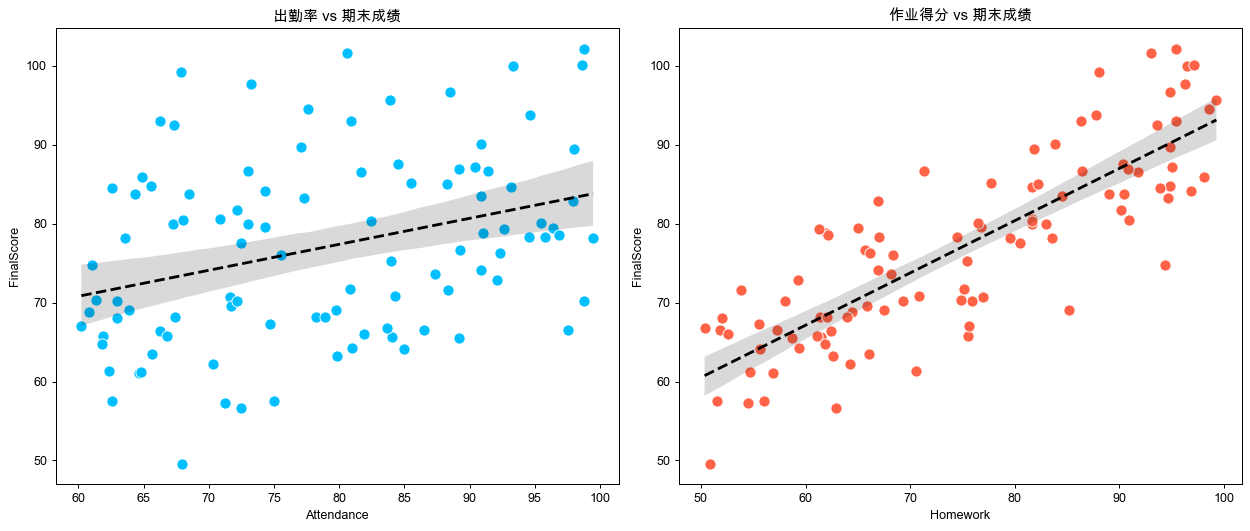

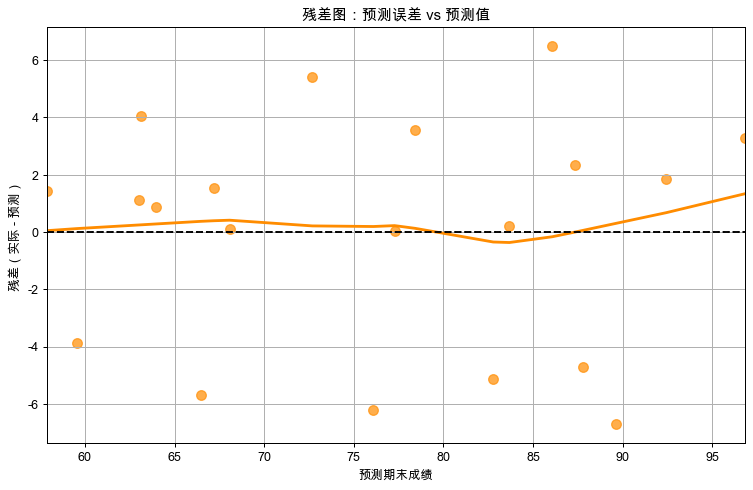

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split


# 1. 生成模拟数据（100 名学生）
np.random.seed(42)
attendance = np.random.uniform(60, 100, 100)          # 出勤率：60% ~ 100%
homework_score = np.random.uniform(50, 100, 100)      # 平时作业：50 ~ 100
final_score = 0.4 * attendance + 0.6 * homework_score + np.random.normal(0, 5, 100)

df = pd.DataFrame({
    'Attendance': attendance,
    'Homework': homework_score,
    'FinalScore': final_score
})

# 2. 数据分布（增强美观和信息量）
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='Attendance', y='FinalScore', color='deepskyblue', s=80)
sns.regplot(data=df, x='Attendance', y='FinalScore', scatter=False, color='black', line_kws={'linestyle': '--'})
plt.title('出勤率 vs 期末成绩')

plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='Homework', y='FinalScore', color='tomato', s=80)
sns.regplot(data=df, x='Homework', y='FinalScore', scatter=False, color='black', line_kws={'linestyle': '--'})
plt.title('作业得分 vs 期末成绩')

plt.tight_layout()
plt.show()


# 3. 构造训练集和测试集
X = df[['Attendance', 'Homework']]
y = df['FinalScore']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. 拟合线性回归模型
model = LinearRegression()
model.fit(X_train, y_train)

# 5. 预测测试集
y_pred = model.predict(X_test)

# 6. 残差图（Residual Plot）
residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
sns.residplot(x=y_pred, y=residuals, lowess=True, color='darkorange', scatter_kws={'alpha':0.7, 's':60})
plt.axhline(0, linestyle='--', color='black')
plt.title('残差图：预测误差 vs 预测值')
plt.xlabel('预测期末成绩')
plt.ylabel('残差（实际 - 预测）')
plt.grid(True)
plt.show()

代码中，模拟了 100 名学生的数据：

- 出勤率与作业得分共同决定期末成绩（权重分别为 0.4 和 0.6）。
- 加入随机噪声，模拟不可预测因素（如临时发挥失常等）。

训练一个多元线性回归模型，学习「出勤率+作业得分」与「期末成绩」的线性关系。

![原文参考图，当前结果见代码输出](attachments/img_013.png)

**1. 数据分布图**：每个变量与目标之间的关系用散点图表示，加入了回归趋势线（黑色虚线），帮助观察变量对成绩的线性影响。

![原文参考图，当前结果见代码输出](attachments/img_014.png)

**2. 残差图**：水平线 = 0：表示预测值 = 实际值，散点越接近 0 线，误差越小。如果残差呈随机分布（无明显模式），说明线性模型拟合得当

## 模型分析

### 优缺点

**优点：**

- **直观易理解**：它的单位和原始数据一样（元），没有平方或开方。
- **鲁棒性好**：对极端离群值不敏感，能防止模型对异常样本过度拟合。
- **更贴近商业用途**：比如房价、销售额等场景，使用 MAE 更符合直觉。

**缺点：**

- **不可导点**：在误差为0的位置，不可导，使得在使用梯度下降等方法时不够平滑。
- **对误差方向不敏感**：正错和负错在 MAE 中效果一样，可能无法区分“高估”或“低估”。

### MAE 与其他损失函数对比

| 损失函数 | 定义公式 | 特点 | 适用场景 |
|-|-|-|-|
| **MAE** (平均绝对误差) | $\frac{1}{n} \sum \\| y_i - \hat{y}\_i \\|$ | 不敏感于异常值，误差线性增长 | 销售额预测、稳健统计 |
| **MSE** (均方误差) | $\frac{1}{n} \sum (y_i - \hat{y}_i)^2$ | 对大误差惩罚更大（平方） | 回归模型、优化更稳定 |
| **Huber 损失** | 结合 MAE 和 MSE，误差小时像 MSE，大时像 MAE | 平衡鲁棒性与可导性 | 既要抗离群又要平滑优化的场合 |

### 什么时候该使用 MAE？

**MAE 是优选的情况：**

- **异常值较多**：比如市场价格、用户评分中，存在极端值时。
- **对方向不敏感**：只关心误差大小，不关心高估或低估。
- **结果要“实打实”解释**：比如“平均误差 1 万元”比“MSE 10000000”更直观。

**不建议使用 MAE 的情况：**

- **对大误差特别敏感的场景**：比如航天器控制，误差平方影响重大。
- **需要二阶导数优化**：比如神经网络训练中，MSE 更平滑、易求导。
- **需要区分误差方向（高估/低估）**：MAE 会丢失这一信息。

## 总结

损失函数 是训练模型的评分标准，MAE（平均绝对误差） 是一种简单、稳定、不敏感于异常值的评估指标。

适用于 销售预测、房价估值等场景，相比 MSE 更稳定但收敛慢；相比 Huber 更易理解但不如其灵活。